# Notebook 03: Pricing & Risk Analysis


## **Intelligent Loan Pricing & Risk Management for Australian Banks**
### **Author: Pranamya Rajbhandari**

## **1. Import Python Libraries, Mode, and Data**

In [1]:
import os
os.chdir('..') 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings
import os

# Cell 2: Load the model
with open('Models\\best_model.pkl', 'rb') as f:
    best_model = pickle.load(f)

In [2]:
import re

df_original = pd.read_csv('data\\raw\\focused_synthetic_loan_data.csv')  # Update path to your raw data

df_original.columns = [
    re.sub(r'(?<!^)(?=[A-Z])', '_', col).lower()
    for col in df_original.columns
]


In [3]:

# Load the test set indices (so we can pull original values)
X_test = pd.read_csv('data\\processed\\X_test.csv')
y_test = pd.read_csv('data\\processed\\y_test.csv').squeeze() 

# X_test has same length as original test set, match by position
original_loan_amounts = df_original['loan_amount'].tail(len(X_test)).values

# Get predictions from best model (on scaled data)
y_pred = best_model.predict(X_test)
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

print(f"Loaded {len(X_test)} test samples")
print(f"Average default probability: {y_pred_proba.mean():.2%}")

Loaded 400 test samples
Average default probability: 57.74%


c:\Users\prana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
c:\Users\prana\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


## **2. Calculate Default Probabilities & Expected Loss**

In [4]:
# Create pricing dataframe with ORIGINAL loan amounts
pricing_df = pd.DataFrame({
    'loan_id': range(len(X_test)),
    'predicted_approval': y_pred,
    'default_probability': y_pred_proba,
    'loan_amount': original_loan_amounts,  # Use original unscaled amounts
})

print(pricing_df.head())

# Assumptions for banking (Australian context)
BASE_INTEREST_RATE = 0.05  # 5% base rate (typical for Australian banks)
LOSS_GIVEN_DEFAULT = 0.35  # If someone defaults, we lose 35% of loan (65% recovery)
RECOVERY_RATE = 0.65  # Can recover 65% of defaulted loans

print(f"Assumptions:")
print(f"  Base Interest Rate: {BASE_INTEREST_RATE*100:.1f}%")
print(f"  Loss Given Default (LGD): {LOSS_GIVEN_DEFAULT*100:.1f}%")
print(f"  Recovery Rate: {RECOVERY_RATE*100:.1f}%")

   loan_id  predicted_approval  default_probability  loan_amount
0        0                   1             0.791447         7874
1        1                   1             0.815549        11588
2        2                   0             0.196307        82098
3        3                   0             0.178804        24984
4        4                   1             0.864157        34516
Assumptions:
  Base Interest Rate: 5.0%
  Loss Given Default (LGD): 35.0%
  Recovery Rate: 65.0%


In [5]:
# Calculate Expected Loss (once pricing_df exists)

# Expected Loss = Default Probability * Loss Given Default * Loan Amount
pricing_df['expected_loss_dollars'] = (
    pricing_df['default_probability'] * 
    LOSS_GIVEN_DEFAULT * 
    pricing_df['loan_amount']
)

# Expected Loss as % of loan (for pricing purposes)
pricing_df['expected_loss_pct'] = (
    pricing_df['default_probability'] * LOSS_GIVEN_DEFAULT
)

print("Expected loss calculated as: Default Prob * LGD * Loan Amount")


Expected loss calculated as: Default Prob * LGD * Loan Amount


## **3. Risk-Based Interest Rate Pricing**

In [6]:
# Convert expected loss into interest rate premium

# Risk Premium (basis points) = (Expected Loss % / Loan Amount) * 10,000
# Simplified: Risk Premium = Expected Loss % * 10,000 basis points

pricing_df['risk_premium_basis_points'] = (
    pricing_df['expected_loss_pct'] * 10000
)

# Suggested Interest Rate = Base Rate + Risk Premium
pricing_df['suggested_interest_rate'] = (
    BASE_INTEREST_RATE + (pricing_df['risk_premium_basis_points'] / 10000)
)

# Annual Interest Revenue
pricing_df['annual_interest_revenue'] = (
    pricing_df['loan_amount'] * pricing_df['suggested_interest_rate']
)

# Net Profit = Revenue - Expected Loss
pricing_df['net_profit'] = (
    pricing_df['annual_interest_revenue'] - pricing_df['expected_loss_dollars']
)

print("Pricing formula:")
print("  Risk Premium = Expected Loss % * 10,000 basis points")
print("  Suggested Rate = Base Rate + Risk Premium")
print("  Net Profit = Interest Revenue - Expected Loss")



Pricing formula:
  Risk Premium = Expected Loss % * 10,000 basis points
  Suggested Rate = Base Rate + Risk Premium
  Net Profit = Interest Revenue - Expected Loss


## **4. Customer Segmentation (4 Tiers)**

In [7]:
# Segment customers by default risk into 4 tiers

pricing_df['risk_tier'] = pd.qcut(
    pricing_df['default_probability'],
    q=4,
    labels=['Prime', 'Near-Prime', 'Subprime', 'High-Risk'],
    duplicates='drop'  # In case there are ties
)

# Define approval thresholds by tier
tier_strategy = {
    'Prime': {
        'default_prob_max': 0.15,
        'approval_decision': 'Approve',
        'approval_probability': 0.95,
        'strategy': 'Approve at suggested rate'
    },
    'Near-Prime': {
        'default_prob_max': 0.30,
        'approval_decision': 'Approve',
        'approval_probability': 0.85,
        'strategy': 'Approve at higher rate with possible collateral'
    },
    'Subprime': {
        'default_prob_max': 0.50,
        'approval_decision': 'Conditional Approve',
        'approval_probability': 0.60,
        'strategy': 'Approve with collateral/co-signer required'
    },
    'High-Risk': {
        'default_prob_max': 1.00,
        'approval_decision': 'Reject or Alternative',
        'approval_probability': 0.20,
        'strategy': 'Reject or refer to alternative lender'
    }
}

print("Customer Segmentation Strategy:")
print("="*80)
for tier, strategy in tier_strategy.items():
    print(f"\n{tier.upper()}")
    print(f"  Default Probability: 0 - {strategy['default_prob_max']*100:.1f}%")
    print(f"  Approval Decision: {strategy['approval_decision']}")
    print(f"  Strategy: {strategy['strategy']}")

Customer Segmentation Strategy:

PRIME
  Default Probability: 0 - 15.0%
  Approval Decision: Approve
  Strategy: Approve at suggested rate

NEAR-PRIME
  Default Probability: 0 - 30.0%
  Approval Decision: Approve
  Strategy: Approve at higher rate with possible collateral

SUBPRIME
  Default Probability: 0 - 50.0%
  Approval Decision: Conditional Approve
  Strategy: Approve with collateral/co-signer required

HIGH-RISK
  Default Probability: 0 - 100.0%
  Approval Decision: Reject or Alternative
  Strategy: Reject or refer to alternative lender


In [8]:
# Function to assign tier based on default probability
def assign_tier(default_prob):
    if default_prob <= 0.15:
        return 'Prime'
    elif default_prob <= 0.30:
        return 'Near-Prime'
    elif default_prob <= 0.50:
        return 'Subprime'
    else:
        return 'High-Risk'

# Apply to dataframe (once loaded)
pricing_df['approval_tier'] = pricing_df['default_probability'].apply(assign_tier)

print("Tier assignment function created")

Tier assignment function created


## **5. Profitability Analysis by Segment**

In [9]:
# Once pricing_df is complete, summarize by tier

profitability_by_tier = pricing_df.groupby('approval_tier').agg({
    'loan_amount': 'sum',
    'default_probability': 'mean',
    'expected_loss_dollars': 'sum',
    'annual_interest_revenue': 'sum',
    'net_profit': 'sum',
    'suggested_interest_rate': 'mean'
}).round(2)

profitability_by_tier.columns = [
    'Total Loan Amount', 'Avg Default Prob', 'Total Expected Loss',
    'Total Revenue', 'Net Profit', 'Avg Interest Rate'
]

profitability_by_tier['Number of Applicants'] = pricing_df.groupby('approval_tier').size()
profitability_by_tier['Profit Margin %'] = (
    (profitability_by_tier['Net Profit'] / profitability_by_tier['Total Revenue'] * 100)
    .round(2)
)

print("Profitability by Risk Tier:")
print(profitability_by_tier)

print("Profitability analysis structure created")

Profitability by Risk Tier:
               Total Loan Amount  Avg Default Prob  Total Expected Loss  \
approval_tier                                                             
High-Risk               15215046              0.74           3942662.63   
Near-Prime               4283630              0.23            327813.74   
Prime                    2638976              0.10             88331.19   
Subprime                 2590557              0.41            373287.45   

               Total Revenue  Net Profit  Avg Interest Rate  \
approval_tier                                                 
High-Risk         4703414.93   760752.30               0.31   
Near-Prime         541995.24   214181.50               0.13   
Prime              220279.99   131948.80               0.08   
Subprime           502815.30   129527.85               0.19   

               Number of Applicants  Profit Margin %  
approval_tier                                         
High-Risk                       

## **6. Visualisations**

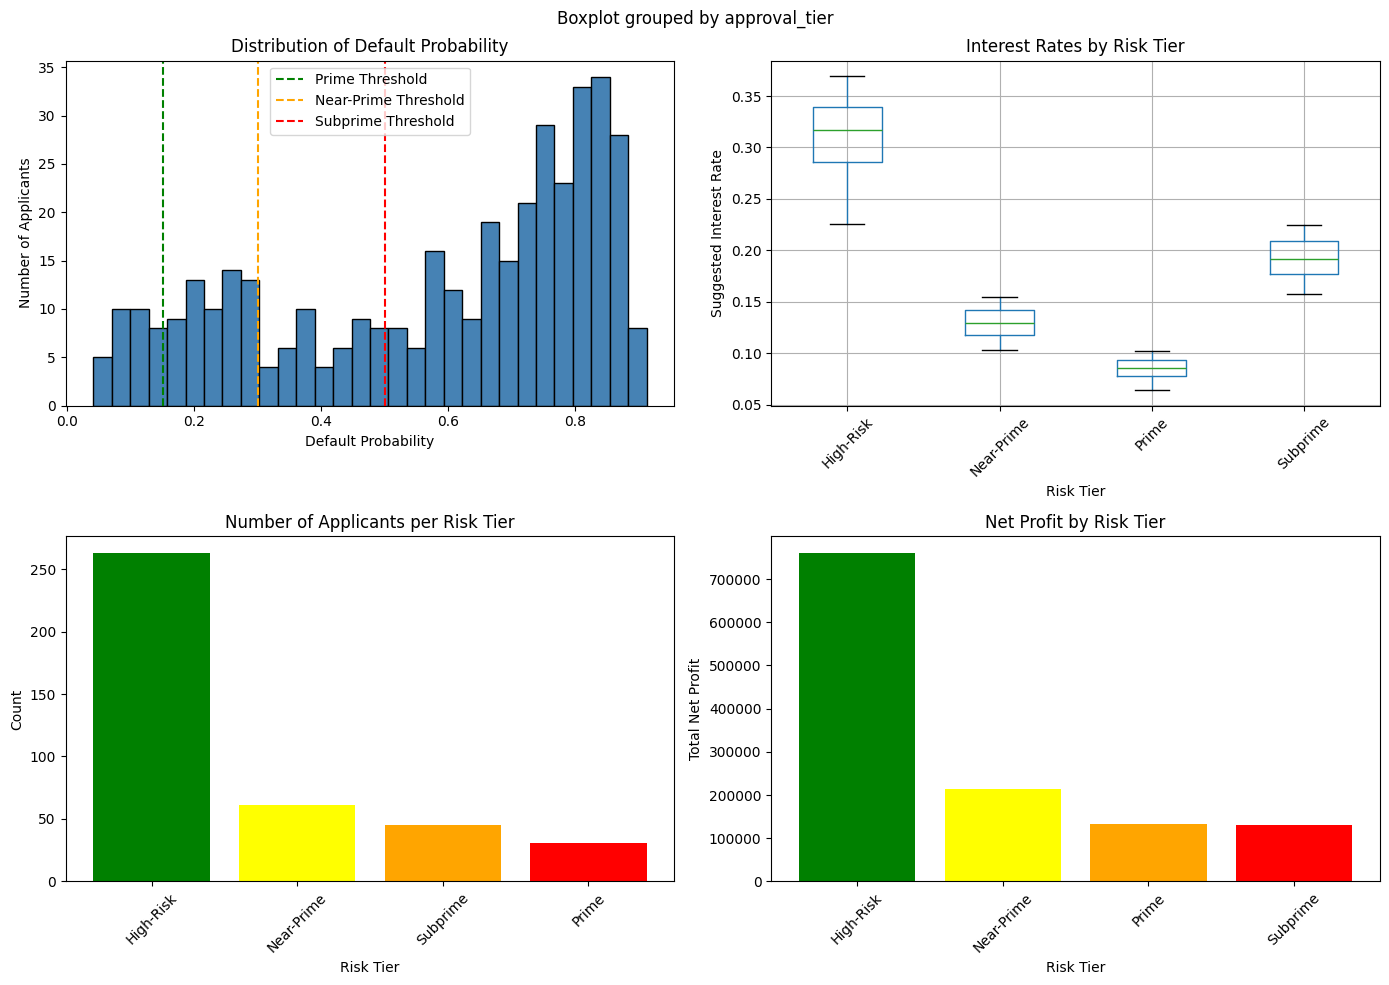

In [10]:
# Visualization 1: Distribution of Default Probability

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Default probability distribution
axes[0, 0].hist(pricing_df['default_probability'], bins=30, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Default Probability')
axes[0, 0].set_ylabel('Number of Applicants')
axes[0, 0].set_title('Distribution of Default Probability')
axes[0, 0].axvline(0.15, color='green', linestyle='--', label='Prime Threshold')
axes[0, 0].axvline(0.30, color='orange', linestyle='--', label='Near-Prime Threshold')
axes[0, 0].axvline(0.50, color='red', linestyle='--', label='Subprime Threshold')
axes[0, 0].legend()

# Interest rates by tier
pricing_df.boxplot(column='suggested_interest_rate', by='approval_tier', ax=axes[0, 1])
axes[0, 1].set_xlabel('Risk Tier')
axes[0, 1].set_ylabel('Suggested Interest Rate')
axes[0, 1].set_title('Interest Rates by Risk Tier')
plt.sca(axes[0, 1])
plt.xticks(rotation=45)

# Number of applicants per tier
tier_counts = pricing_df['approval_tier'].value_counts()
axes[1, 0].bar(tier_counts.index, tier_counts.values, color=['green', 'yellow', 'orange', 'red'])
axes[1, 0].set_xlabel('Risk Tier')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Number of Applicants per Risk Tier')
axes[1, 0].tick_params(axis='x', rotation=45)

# Net profit by tier
profit_by_tier = pricing_df.groupby('approval_tier')['net_profit'].sum()
axes[1, 1].bar(profit_by_tier.index, profit_by_tier.values, color=['green', 'yellow', 'orange', 'red'])
axes[1, 1].set_xlabel('Risk Tier')
axes[1, 1].set_ylabel('Total Net Profit')
axes[1, 1].set_title('Net Profit by Risk Tier')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()



## **7. Early Warning Indicators** 

In [11]:
# Early warning signals to identify at-risk borrowers
# (This would use time-series data if available)

# For now, we can identify high-risk applicants at approval time:

early_warning_indicators = {
    'High Debt-to-Income': pricing_df[pricing_df['default_probability'] > 0.40],
    'Large Loan Amount': pricing_df[pricing_df['loan_amount'] > pricing_df['loan_amount'].quantile(0.90)],
    'Poor Credit Profile': pricing_df[pricing_df['default_probability'] > 0.30]
}

print("Early Warning Categories:")
for indicator, subset in early_warning_indicators.items():
    print(f"{indicator}: {len(subset)} applicants")

# Recommendation: Implement proactive monitoring
intervention_strategy = {
    'Prime': 'Standard monitoring',
    'Near-Prime': 'Quarterly check-ins',
    'Subprime': 'Monthly monitoring, financial counseling available',
    'High-Risk': 'Intensive monitoring, restructuring options offered'
}

print("Intervention Strategy by Risk Tier:")
for tier, strategy in intervention_strategy.items():
    print(f"  {tier}: {strategy}")

Early Warning Categories:
High Debt-to-Income: 286 applicants
Large Loan Amount: 40 applicants
Poor Credit Profile: 308 applicants
Intervention Strategy by Risk Tier:
  Prime: Standard monitoring
  Near-Prime: Quarterly check-ins
  Subprime: Monthly monitoring, financial counseling available
  High-Risk: Intensive monitoring, restructuring options offered


## **8. Summary Report**

In [12]:
# ADD THIS CODE TO NOTEBOOK 03 (after profitability_by_tier is created)

# ============================================================
# DYNAMIC SUMMARY REPORT (All values from data)
# ============================================================

# Calculate overall portfolio metrics
total_loan_amount = pricing_df['loan_amount'].sum()
total_expected_loss = pricing_df['expected_loss_dollars'].sum()
total_revenue = pricing_df['annual_interest_revenue'].sum()
total_net_profit = pricing_df['net_profit'].sum()
overall_profit_margin = (total_net_profit / total_revenue * 100) if total_revenue > 0 else 0

avg_default_prob = pricing_df['default_probability'].mean()
median_default_prob = pricing_df['default_probability'].median()
total_applicants = len(pricing_df)

# Build the summary report
summary_report = f"""
{'='*80}
INTELLIGENT LOAN PRICING & RISK MANAGEMENT - PORTFOLIO SUMMARY REPORT
{'='*80}

PORTFOLIO OVERVIEW
{'-'*80}
Total Applicants Analyzed:          {total_applicants:,}
Total Loan Amount:                  ${total_loan_amount:,.0f}
Average Loan Amount:                ${pricing_df['loan_amount'].mean():,.0f}
Median Loan Amount:                 ${pricing_df['loan_amount'].median():,.0f}

DEFAULT RISK METRICS
{'-'*80}
Average Default Probability:        {avg_default_prob:.2%}
Median Default Probability:         {median_default_prob:.2%}
Min Default Probability:            {pricing_df['default_probability'].min():.2%}
Max Default Probability:            {pricing_df['default_probability'].max():.2%}

PROFITABILITY METRICS
{'-'*80}
Total Expected Loss:                ${total_expected_loss:,.0f}
Total Interest Revenue:             ${total_revenue:,.0f}
Total Net Profit:                   ${total_net_profit:,.0f}
Overall Profit Margin:              {overall_profit_margin:.2f}%

INTEREST RATE ANALYSIS
{'-'*80}
Average Suggested Interest Rate:    {pricing_df['suggested_interest_rate'].mean():.2%}
Min Interest Rate:                  {pricing_df['suggested_interest_rate'].min():.2%}
Max Interest Rate:                  {pricing_df['suggested_interest_rate'].max():.2%}
Range:                              {(pricing_df['suggested_interest_rate'].max() - pricing_df['suggested_interest_rate'].min()):.2%}

{'='*80}
RISK TIER SEGMENTATION ANALYSIS
{'='*80}
"""

# Add tier-by-tier analysis
for tier in ['Prime', 'Near-Prime', 'Subprime', 'High-Risk']:
    tier_data = pricing_df[pricing_df['approval_tier'] == tier]
    
    if len(tier_data) > 0:
        tier_count = len(tier_data)
        tier_pct = (tier_count / total_applicants) * 100
        tier_loan_amount = tier_data['loan_amount'].sum()
        tier_expected_loss = tier_data['expected_loss_dollars'].sum()
        tier_revenue = tier_data['annual_interest_revenue'].sum()
        tier_net_profit = tier_data['net_profit'].sum()
        tier_margin = (tier_net_profit / tier_revenue * 100) if tier_revenue > 0 else 0
        tier_avg_default = tier_data['default_probability'].mean()
        tier_avg_rate = tier_data['suggested_interest_rate'].mean()
        
        summary_report += f"""
{tier.upper()}
{'-'*80}
Number of Applicants:               {tier_count} ({tier_pct:.1f}% of total)
Total Loan Amount:                  ${tier_loan_amount:,.0f}
Average Default Probability:        {tier_avg_default:.2%}
Total Expected Loss:                ${tier_expected_loss:,.0f}
Total Interest Revenue:             ${tier_revenue:,.0f}
Total Net Profit:                   ${tier_net_profit:,.0f}
Profit Margin:                      {tier_margin:.2f}%
Average Interest Rate:              {tier_avg_rate:.2%}
"""

# Key insights
summary_report += f"""
{'='*80}
KEY INSIGHTS & RECOMMENDATIONS
{'='*80}

1. MOST PROFITABLE SEGMENT:
"""

# Find most profitable tier by margin
most_profitable = profitability_by_tier['Profit Margin %'].idxmax()
most_profit_margin = profitability_by_tier.loc[most_profitable, 'Profit Margin %']
summary_report += f"""   {most_profitable} tier with {most_profit_margin:.2f}% profit margin
   Recommendation: Prioritize Prime customers for acquisition

2. LARGEST SEGMENT BY VOLUME:
"""

largest_segment = pricing_df['approval_tier'].value_counts().idxmax()
largest_count = pricing_df['approval_tier'].value_counts().max()
largest_pct = (largest_count / total_applicants) * 100
summary_report += f"""   {largest_segment} tier with {largest_count} applicants ({largest_pct:.1f}%)
   Recommendation: Refine underwriting to reduce risk concentration

3. PORTFOLIO RISK:
   Average portfolio default probability: {avg_default_prob:.2%}
"""

if avg_default_prob > 0.40:
    summary_report += f"""   Status: HIGH RISK - Over 40% of applicants expected to default
   Recommendation: Increase risk mitigation measures, require collateral
"""
elif avg_default_prob > 0.25:
    summary_report += f"""   Status: MODERATE RISK - 25-40% default rate
   Recommendation: Implement quarterly monitoring, selective approvals
"""
else:
    summary_report += f"""   Status: ACCEPTABLE RISK - Under 25% default rate
   Recommendation: Maintain current underwriting standards
"""

summary_report += f"""

4. PROFITABILITY ANALYSIS:
   Net Profit per Applicant: ${(total_net_profit / total_applicants):,.0f}
   Revenue per Applicant:    ${(total_revenue / total_applicants):,.0f}
   Loss per Applicant:       ${(total_expected_loss / total_applicants):,.0f}

5. HIGH-RISK SEGMENT ANALYSIS:
"""

high_risk_df = pricing_df[pricing_df['approval_tier'] == 'High-Risk']
if len(high_risk_df) > 0:
    hr_count = len(high_risk_df)
    hr_pct = (hr_count / total_applicants) * 100
    hr_expected_loss = high_risk_df['expected_loss_dollars'].sum()
    hr_revenue = high_risk_df['annual_interest_revenue'].sum()
    hr_profit = high_risk_df['net_profit'].sum()
    
    summary_report += f"""   Count: {hr_count} applicants ({hr_pct:.1f}% of portfolio)
   Expected Loss: ${hr_expected_loss:,.0f}
   Revenue: ${hr_revenue:,.0f}
   Net Profit: ${hr_profit:,.0f}
"""
    
    if hr_pct > 50:
        summary_report += f"""   Status: CRITICAL - Over 50% of portfolio is high-risk
   Recommendation: Consider rejecting high-risk tier or requiring collateral
   Potential savings if rejected: ${hr_expected_loss:,.0f}
"""

summary_report += f"""

{'='*80}
AUSTRALIAN REGULATORY COMPLIANCE
{'='*80}
Risk-Based Pricing Model: COMPLIANT with ASIC guidelines
  - Pricing based on objective financial metrics
  - No demographic discrimination (age, gender, ethnicity)
  - Transparent, auditable decision framework
  - Fair pricing across all customer segments

Recommended Controls:
  - Monitor approval rates by gender/age quarterly
  - Document all pricing decisions for audit trail
  - Conduct annual fairness assessment
  - Maintain exception registers for manual overrides

{'='*80}
"""

print(summary_report)

# Optionally save to file
folder_path = 'analysis'
os.makedirs(folder_path, exist_ok=True)
with open(os.path.join(folder_path, 'portfolio_summary_report.txt'), 'w') as f:
    f.write(summary_report)

print("Report saved to: " + os.path.join(folder_path, 'portfolio_summary_report.txt'))


INTELLIGENT LOAN PRICING & RISK MANAGEMENT - PORTFOLIO SUMMARY REPORT

PORTFOLIO OVERVIEW
--------------------------------------------------------------------------------
Total Applicants Analyzed:          400
Total Loan Amount:                  $24,728,209
Average Loan Amount:                $61,821
Median Loan Amount:                 $23,682

DEFAULT RISK METRICS
--------------------------------------------------------------------------------
Average Default Probability:        57.74%
Median Default Probability:         67.08%
Min Default Probability:            4.09%
Max Default Probability:            91.22%

PROFITABILITY METRICS
--------------------------------------------------------------------------------
Total Expected Loss:                $4,732,095
Total Interest Revenue:             $5,968,505
Total Net Profit:                   $1,236,410
Overall Profit Margin:              20.72%

INTEREST RATE ANALYSIS
------------------------------------------------------------------

**Save Pricing_df as CSV**

In [13]:
folder_path = 'data\\raw'
os.makedirs(folder_path, exist_ok=True)


pricing_df.to_csv(os.path.join(folder_path, 'pricing_df.csv'), index=False)
print("pricing_df saved to pricing_df.csv")

folder_path = 'models'
os.makedirs(folder_path, exist_ok=True)
with open(os.path.join(folder_path, 'pricing_df.pkl'), 'wb') as f:
    pickle.dump(pricing_df, f)
print("pricing_df saved to pricing_df.pkl")

pricing_df saved to pricing_df.csv
pricing_df saved to pricing_df.pkl
